# 🫁 Lung Cancer Segmentation — Gradio App (nnU-Net)
Run cells sequentially.

## CELL 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_RESULTS = '/content/drive/MyDrive/nnunet_lung/nnUNet_results'

NNUNET_TRAINER  = 'nnUNetTrainer_10epochs'
NNUNET_PLANS    = 'nnUNetResEncUNetMPlans'
NNUNET_FOLD     = '0'
NNUNET_DATASET  = '1'
DEVICE          = 'cuda'

NNUNET_RAW          = '/content/nnunet/raw'
NNUNET_PREPROCESSED = '/content/nnunet/preprocessed'
NNUNET_RESULTS      = DRIVE_RESULTS

os.environ['nnUNet_raw']          = NNUNET_RAW
os.environ['nnUNet_preprocessed'] = NNUNET_PREPROCESSED
os.environ['nnUNet_results']      = NNUNET_RESULTS

for d in [NNUNET_RAW, NNUNET_PREPROCESSED, '/content/outputs', '/content/work']:
    os.makedirs(d, exist_ok=True)

print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## CELL 2 — Install dependencies

In [ ]:
!pip install -q nnunetv2 huggingface_hub nibabel pydicom gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 7.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## CELL 3 — Verify GPU

In [ ]:
import torch
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No GPU")

Tesla T4


## CELL 4 — Patient listing

In [ ]:
import functools
from huggingface_hub import HfApi

HF_DATASET_REPO = 'farrell236/NSCLC-Radiomics-NIFTI'
_hf_api = HfApi()

@functools.lru_cache(maxsize=1)
def get_patient_list():
    files = _hf_api.list_repo_files(repo_id=HF_DATASET_REPO, repo_type='dataset')
    print(f"Total files found in repository: {len(files)}")
    if files:
        print(f"First 5 files: {files[:5]}")

    patients = set()
    for f in files:
        parts = f.split('/')
        # Check if the path has enough parts and if the second part starts with 'LUNG1-'
        if len(parts) > 1 and parts[1].startswith('LUNG1-'):
            patients.add(parts[1])

    print(f"Unique patients found after filtering: {len(patients)}")
    if patients:
        print(f"Sample patients (first 5 sorted): {sorted(list(patients))[:5]}")

    patients = sorted(list(patients))
    return patients

PATIENT_LIST = get_patient_list()
print(PATIENT_LIST[:5])

Total files found in repository: 2885
First 5 files: ['.gitattributes', 'LICENSE', 'NSCLC-Radiomics-NIFTI/LUNG1-001/image.nii.gz', 'NSCLC-Radiomics-NIFTI/LUNG1-001/seg-GTV-1.nii.gz', 'NSCLC-Radiomics-NIFTI/LUNG1-001/seg-Lung-Left.nii.gz']
Unique patients found after filtering: 422
Sample patients (first 5 sorted): ['LUNG1-001', 'LUNG1-002', 'LUNG1-003', 'LUNG1-004', 'LUNG1-005']
['LUNG1-001', 'LUNG1-002', 'LUNG1-003', 'LUNG1-004', 'LUNG1-005']


## CELL 5 — Pipeline functions

In [ ]:

import shutil
import subprocess
import json
import datetime
import numpy as np
import nibabel as nib
import pydicom
from pathlib import Path
from pydicom.dataset import Dataset, FileDataset
from pydicom.sequence import Sequence
from pydicom.uid import generate_uid
from huggingface_hub import snapshot_download


# ── 1. Download patient ───────────────────────────────────────────────

def download_patient(patient_id: str, work_dir: Path) -> Path:
    dest = work_dir / 'hf_data'
    dest.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id=HF_DATASET_REPO,
        repo_type='dataset',
        local_dir=str(dest),
        allow_patterns=[f'*{patient_id}/*.nii.gz', f'*{patient_id}/*.nii'],
        ignore_patterns=[
            'seg-Esophagus*', 'seg-Heart*',
            'seg-Lung-Left*', 'seg-Lung-Right*', 'seg-Spinal*',
            '*.parquet', '*.json', '*.csv',
        ],
    )
    return dest


def find_ct(patient_dir: Path) -> Path:
    skip = ['seg-', 'label', 'mask', 'gtv', 'esophagus',
            'heart', 'lung-left', 'lung-right', 'spinal']
    candidates = [
        f for f in patient_dir.rglob('*.nii.gz')
        if not any(k in f.name.lower() for k in skip)
    ]
    if not candidates:
        raise FileNotFoundError(f'No CT NIfTI found in {patient_dir}')
    return max(candidates, key=lambda p: p.stat().st_size)


# ── 2. Stage nnU-Net input ────────────────────────────────────────────

def stage_input(ct_path: Path, case_id: str, work_dir: Path) -> Path:
    images_dir = work_dir / 'imagesTs'
    images_dir.mkdir(parents=True, exist_ok=True)
    dest = images_dir / f'{case_id}_0000.nii.gz'
    shutil.copy2(ct_path, dest)

    # dataset.json (required by nnU-Net predict)
    ds_dir = Path(NNUNET_RAW) / f'Dataset{NNUNET_DATASET.zfill(3)}_LungCancer'
    ds_dir.mkdir(parents=True, exist_ok=True)
    (ds_dir / 'dataset.json').write_text(json.dumps({
        'channel_names': {'0': 'CT'},
        'labels': {'background': 0, 'tumour': 1},
        'numTraining': 82,
        'file_ending': '.nii.gz',
        'name': 'Dataset001_LungCancer',
    }, indent=2))
    return images_dir


# ── 3. Run nnU-Net predict ────────────────────────────────────────────

def run_predict(images_dir: Path, predict_out: Path):
    predict_out.mkdir(parents=True, exist_ok=True)
    cmd = [
        'nnUNetv2_predict',
        '-i', str(images_dir),
        '-o', str(predict_out),
        '-d', NNUNET_DATASET,
        '-c', '3d_lowres',
        '-tr', NNUNET_TRAINER,
        '-p', NNUNET_PLANS,
        '-f', NNUNET_FOLD,
        '-device', DEVICE,
    ]
    print('Running:', ' '.join(cmd))
    result = subprocess.run(cmd, text=True)
    if result.returncode != 0:
        raise RuntimeError(f'nnUNetv2_predict failed (exit {result.returncode})')
    masks = list(predict_out.glob('*.nii.gz'))
    if not masks:
        raise FileNotFoundError('nnU-Net produced no output mask.')
    return masks[0]


# ── 4. NIfTI → DICOM-SEG ─────────────────────────────────────────────

def convert_to_dicom_seg(mask_path: Path, patient_id: str) -> Path:
    img     = nib.load(mask_path)
    arr     = img.get_fdata().astype(np.uint8)
    spacing = list(img.header.get_zooms())
    rows, cols, n_slices = arr.shape

    now = datetime.datetime.now()

    file_meta = Dataset()
    file_meta.MediaStorageSOPClassUID    = '1.2.840.10008.5.1.4.1.1.66.4'
    file_meta.MediaStorageSOPInstanceUID = generate_uid()
    file_meta.TransferSyntaxUID          = '1.2.840.10008.1.2.1'
    file_meta.ImplementationClassUID     = generate_uid()

    ds = FileDataset('', {}, file_meta=file_meta, preamble=b'\x00' * 128)
    ds.is_implicit_VR   = False
    ds.is_little_endian = True

    ds.PatientID              = patient_id
    ds.PatientName            = patient_id
    ds.StudyInstanceUID       = generate_uid()
    ds.SeriesInstanceUID      = generate_uid()
    ds.SOPClassUID            = '1.2.840.10008.5.1.4.1.1.66.4'
    ds.SOPInstanceUID         = file_meta.MediaStorageSOPInstanceUID
    ds.Modality               = 'SEG'
    ds.StudyDate              = now.strftime('%Y%m%d')
    ds.ContentDate            = now.strftime('%Y%m%d')
    ds.StudyTime              = now.strftime('%H%M%S')
    ds.ContentTime            = now.strftime('%H%M%S')
    ds.Manufacturer           = 'nnU-Net'
    ds.SeriesDescription      = f'Lung tumour — {patient_id}'
    ds.ContentLabel           = 'LUNG_SEG'
    ds.InstanceNumber         = '1'

    ds.Rows                      = rows
    ds.Columns                   = cols
    ds.NumberOfFrames            = n_slices
    ds.PixelSpacing              = [f'{spacing[0]:.4f}', f'{spacing[1]:.4f}']
    ds.SliceThickness            = f'{spacing[2]:.4f}'
    ds.ImageOrientationPatient   = [1, 0, 0, 0, 1, 0]
    ds.ImagePositionPatient      = [0, 0, 0]
    ds.SegmentationType          = 'BINARY'
    ds.BitsAllocated             = 8
    ds.BitsStored                = 8
    ds.HighBit                   = 7
    ds.PixelRepresentation       = 0
    ds.LossyImageCompression     = '00'
    ds.SegmentsOverlap           = 'NO'
    ds.SamplesPerPixel           = 1
    ds.PhotometricInterpretation = 'MONOCHROME2'

    seg_item = Dataset()
    seg_item.SegmentNumber         = 1
    seg_item.SegmentLabel          = 'Lung Tumour'
    seg_item.SegmentDescription    = 'Primary lung tumour (GTV) — nnU-Net'
    seg_item.SegmentAlgorithmType  = 'AUTOMATIC'
    ds.SegmentSequence = Sequence([seg_item])

    shared_fg = Dataset()
    pm = Dataset()
    pm.PixelSpacing   = ds.PixelSpacing
    pm.SliceThickness = ds.SliceThickness
    shared_fg.PixelMeasuresSequence = Sequence([pm])
    ds.SharedFunctionalGroupsSequence = Sequence([shared_fg])

    per_frame = []
    for z in range(n_slices):
        fg = Dataset()
        pp = Dataset()
        pp.ImagePositionPatient = [0, 0, round(z * spacing[2], 4)]
        fg.PlanePositionSequence = Sequence([pp])
        ref = Dataset()
        ref.ReferencedSegmentNumber = 1
        fg.SegmentIdentificationSequence = Sequence([ref])
        per_frame.append(fg)
    ds.PerFrameFunctionalGroupsSequence = Sequence(per_frame)

    ds.PixelData = b''.join(arr[:, :, z].tobytes() for z in range(n_slices))

    out = mask_path.parent / mask_path.name.replace('_seg_mask.nii.gz', '_seg.dcm')
    pydicom.dcmwrite(str(out), ds, write_like_original=False)
    return out


# ── 5. Full pipeline ──────────────────────────────────────────────────

def run_pipeline(patient_id: str) -> dict:
    """Run everything for one patient. Returns paths to output files."""
    work_dir   = Path(f'/content/work/{patient_id}')
    output_dir = Path(f'/content/outputs/{patient_id}')
    work_dir.mkdir(parents=True, exist_ok=True)
    output_dir.mkdir(parents=True, exist_ok=True)

    # 1. Download
    patient_dir = download_patient(patient_id, work_dir)

    # 2. Find CT
    ct_path = find_ct(patient_dir)
    num     = patient_id.replace('LUNG1-', '').zfill(3)
    case_id = f'lung_{num}'

    # 3. Stage
    images_dir = stage_input(ct_path, case_id, work_dir)

    # 4. Predict
    predict_out = work_dir / 'predictions'
    raw_mask    = run_predict(images_dir, predict_out)

    # 5. Copy mask to output dir
    final_mask = output_dir / f'{patient_id}_seg_mask.nii.gz'
    shutil.copy2(raw_mask, final_mask)

    # 6. Convert to DICOM-SEG
    raw_dcm   = convert_to_dicom_seg(final_mask, patient_id)
    final_dcm = output_dir / raw_dcm.name
    shutil.move(str(raw_dcm), str(final_dcm))

    # 7. Cleanup work dir
    shutil.rmtree(work_dir, ignore_errors=True)

    tumour_voxels = int((nib.load(final_mask).get_fdata() == 1).sum())

    return {
        'nifti_path' : str(final_mask),
        'dicom_path' : str(final_dcm),
        'tumour_voxels': tumour_voxels,
    }

print('✓ Pipeline functions loaded.')



✓ Pipeline functions loaded.


In [ ]:
# @title CELL 5b — patches run_pipeline() to also save the CT NIfTI into the output folder


# ════════════════════════════════════════════════════════════════════
# CELL 5b — Patch pipeline to save CT alongside the mask
# Run this once after Cell 5. No other changes needed.
# ════════════════════════════════════════════════════════════════════
import shutil
import numpy as np
from pathlib import Path
import nibabel as nib
from huggingface_hub import snapshot_download


def _find_gtv_mask(patient_dir: Path):
    """Find the GTV-1 segmentation NIfTI in the downloaded patient folder."""
    for f in sorted(patient_dir.rglob('*.nii.gz')):
        name = f.name.lower()
        if 'gtv' in name or 'tumor' in name or 'tumour' in name:
            return f
    return None


def run_pipeline(patient_id: str) -> dict:
    """
    Patched pipeline — saves CT + ground truth GTV mask + prediction mask.
    GT is downloaded from the same HF dataset folder as the CT.
    """
    work_dir   = Path(f'/content/work/{patient_id}')
    output_dir = Path(f'/content/outputs/{patient_id}')
    work_dir.mkdir(parents=True, exist_ok=True)
    output_dir.mkdir(parents=True, exist_ok=True)

    # ── 1. Download CT + GTV mask from HuggingFace ────────────────────
    hf_dest = work_dir / 'hf_data'
    hf_dest.mkdir(parents=True, exist_ok=True)
    print(f'  Downloading CT + GTV mask for {patient_id} ...')
    snapshot_download(
        repo_id=HF_DATASET_REPO,
        repo_type='dataset',
        local_dir=str(hf_dest),
        allow_patterns=[
            f'*{patient_id}/*.nii.gz',
            f'*{patient_id}/*.nii',
        ],
        ignore_patterns=[
            # Only skip non-GTV segmentations
            'seg-Esophagus*', 'seg-Heart*',
            'seg-Lung-Left*', 'seg-Lung-Right*', 'seg-Spinal*',
            '*.parquet', '*.json', '*.csv',
        ],
    )

    # ── 2. Find CT and GTV ────────────────────────────────────────────
    ct_path  = find_ct(hf_dest)
    gtv_path = _find_gtv_mask(hf_dest)

    if gtv_path:
        print(f'  GT mask found : {gtv_path.name}')
    else:
        print('  ⚠ No GTV mask found in dataset for this patient.')

    num     = patient_id.replace('LUNG1-', '').zfill(3)
    case_id = f'lung_{num}'

    # ── 3. Save CT ────────────────────────────────────────────────────
    saved_ct = output_dir / f'{patient_id}_ct.nii.gz'
    if not saved_ct.exists():
        shutil.copy2(ct_path, saved_ct)
        print(f'  Saved CT      → {saved_ct.name}')

    # ── 4. Save + binarise ground truth mask ─────────────────────────
    saved_gt = output_dir / f'{patient_id}_gt_mask.nii.gz'
    if gtv_path and not saved_gt.exists():
        gt_img = nib.load(gtv_path)
        gt_arr = (gt_img.get_fdata() > 0).astype(np.uint8)
        nib.save(nib.Nifti1Image(gt_arr, gt_img.affine, gt_img.header), saved_gt)
        print(f'  Saved GT mask → {saved_gt.name}  ({int(gt_arr.sum()):,} voxels)')

    # ── 5. Stage nnU-Net input ────────────────────────────────────────
    images_dir = stage_input(ct_path, case_id, work_dir)

    # ── 6. Predict ────────────────────────────────────────────────────
    predict_out = work_dir / 'predictions'
    raw_mask    = run_predict(images_dir, predict_out)

    # ── 7. Save prediction mask ───────────────────────────────────────
    final_mask = output_dir / f'{patient_id}_seg_mask.nii.gz'
    shutil.copy2(raw_mask, final_mask)

    # ── 8. DICOM-SEG ─────────────────────────────────────────────────
    raw_dcm   = convert_to_dicom_seg(final_mask, patient_id)
    final_dcm = output_dir / raw_dcm.name
    shutil.move(str(raw_dcm), str(final_dcm))

    # ── 9. Cleanup work dir ───────────────────────────────────────────
    shutil.rmtree(work_dir, ignore_errors=True)

    tumour_voxels = int((nib.load(final_mask).get_fdata() == 1).sum())

    return {
        'nifti_path'    : str(final_mask),
        'dicom_path'    : str(final_dcm),
        'ct_path'       : str(saved_ct),
        'gt_path'       : str(saved_gt) if gtv_path else None,
        'tumour_voxels' : tumour_voxels,
    }


In [ ]:

import zipfile
import datetime
import numpy as np
import nibabel as nib
import pydicom
from pathlib import Path
from pydicom.dataset import Dataset, FileDataset
from pydicom.sequence import Sequence
from pydicom.uid import generate_uid


# ── shared helpers ────────────────────────────────────────────────────

def _make_file_meta(sop_class_uid: str, sop_instance_uid: str) -> Dataset:
    fm = Dataset()
    fm.MediaStorageSOPClassUID    = sop_class_uid
    fm.MediaStorageSOPInstanceUID = sop_instance_uid
    fm.TransferSyntaxUID          = '1.2.840.10008.1.2.1'  # Explicit VR LE
    fm.ImplementationClassUID     = '1.2.826.0.1.3680043.10.511'
    return fm


def _base_dataset(file_meta, patient_id, study_uid,
                  frame_of_ref_uid, now) -> FileDataset:
    ds = FileDataset('', {}, file_meta=file_meta, preamble=b'\x00' * 128)
    ds.is_implicit_VR        = False
    ds.is_little_endian      = True
    ds.PatientID             = patient_id
    ds.PatientName           = patient_id
    ds.StudyInstanceUID      = study_uid
    ds.FrameOfReferenceUID   = frame_of_ref_uid   # CRITICAL: identical in CT + SEG
    ds.StudyDate             = now.strftime('%Y%m%d')
    ds.StudyTime             = now.strftime('%H%M%S')
    ds.ContentDate           = now.strftime('%Y%m%d')
    ds.ContentTime           = now.strftime('%H%M%S')
    ds.AccessionNumber       = ''
    ds.Manufacturer          = 'nnU-Net'
    return ds


def _iop_and_ipp(affine, z):
    """Return ImageOrientationPatient and ImagePositionPatient for slice z."""
    col_cos = affine[:3, 0] / np.linalg.norm(affine[:3, 0])
    row_cos = affine[:3, 1] / np.linalg.norm(affine[:3, 1])
    iop     = [round(float(v), 6) for v in list(col_cos) + list(row_cos)]
    origin  = affine @ np.array([0, 0, z, 1])
    ipp     = [round(float(origin[i]), 4) for i in range(3)]
    return iop, ipp


# ── 1. CT series ──────────────────────────────────────────────────────

def _write_ct_series(ct_nifti_path: Path, out_dir: Path,
                     patient_id: str, study_uid: str,
                     frame_of_ref_uid: str, series_uid: str,
                     now: datetime.datetime) -> list:
    """
    One DICOM CT file per axial slice, written flat into out_dir.
    Returns list of SOP Instance UIDs in slice order.
    """
    ct_img  = nib.load(ct_nifti_path)
    ct_arr  = np.clip(ct_img.get_fdata().astype(np.float32), -1024, 3071)
    affine  = ct_img.affine
    spacing = list(ct_img.header.get_zooms())
    rows, cols, n_slices = ct_arr.shape

    sop_uids = []
    for z in range(n_slices):
        sop_uid = generate_uid()
        sop_uids.append(sop_uid)
        iop, ipp = _iop_and_ipp(affine, z)

        fm = _make_file_meta('1.2.840.10008.5.1.4.1.1.2', sop_uid)
        ds = _base_dataset(fm, patient_id, study_uid, frame_of_ref_uid, now)

        ds.SOPClassUID             = '1.2.840.10008.5.1.4.1.1.2'
        ds.SOPInstanceUID          = sop_uid
        ds.Modality                = 'CT'
        ds.SeriesInstanceUID       = series_uid
        ds.SeriesDescription       = f'CT — {patient_id}'
        ds.SeriesNumber            = '1'
        ds.InstanceNumber          = str(z + 1)
        ds.SliceLocation           = round(float(affine[2, 3] + z * spacing[2]), 4)
        ds.Rows                    = rows
        ds.Columns                 = cols
        ds.ImageOrientationPatient = iop
        ds.ImagePositionPatient    = ipp
        ds.PixelSpacing            = [f'{spacing[0]:.4f}', f'{spacing[1]:.4f}']
        ds.SliceThickness          = f'{spacing[2]:.4f}'
        ds.SamplesPerPixel         = 1
        ds.PhotometricInterpretation = 'MONOCHROME2'
        ds.BitsAllocated           = 16
        ds.BitsStored              = 16
        ds.HighBit                 = 15
        ds.PixelRepresentation     = 1  # signed
        ds.RescaleIntercept        = 0
        ds.RescaleSlope            = 1
        ds.RescaleType             = 'HU'
        ds.WindowCenter            = '40'
        ds.WindowWidth             = '400'
        ds.PixelData               = ct_arr[:, :, z].T.astype(np.int16).tobytes()

        pydicom.dcmwrite(str(out_dir / f'CT_{z+1:04d}.dcm'), ds,
                         write_like_original=False)

    print(f'  CT series  → {n_slices} slices written')
    return sop_uids


# ── 2. DICOM-SEG ──────────────────────────────────────────────────────

def _write_dicom_seg(mask_nifti_path: Path, out_dir: Path,
                     patient_id: str, study_uid: str,
                     frame_of_ref_uid: str,
                     ct_series_uid: str, ct_sop_uids: list,
                     now: datetime.datetime) -> Path:
    """
    OHIF v3-compatible DICOM-SEG.  Three fixes over the previous version:
      1. FrameOfReferenceUID shared with CT  →  OHIF can spatially register
      2. DerivationCodeSequence on segment   →  resolves representationData
      3. BitsAllocated/Stored = 8 (1 byte/px) → avoids packbits alignment crash
         (BINARY SegmentationType is still correct; storage width != seg type)
    """
    seg_img  = nib.load(mask_nifti_path)
    seg_arr  = seg_img.get_fdata().astype(np.uint8)
    affine   = seg_img.affine
    spacing  = list(seg_img.header.get_zooms())
    rows, cols, n_slices = seg_arr.shape

    iop, _ = _iop_and_ipp(affine, 0)

    sop_uid = generate_uid()
    fm      = _make_file_meta('1.2.840.10008.5.1.4.1.1.66.4', sop_uid)
    ds      = _base_dataset(fm, patient_id, study_uid, frame_of_ref_uid, now)

    ds.SOPClassUID            = '1.2.840.10008.5.1.4.1.1.66.4'
    ds.SOPInstanceUID         = sop_uid
    ds.Modality               = 'SEG'
    ds.SeriesInstanceUID      = generate_uid()
    ds.SeriesDescription      = f'Lung tumour segmentation — {patient_id}'
    ds.SeriesNumber           = '2'
    ds.InstanceNumber         = '1'
    ds.ContentLabel           = 'LUNG_SEG'
    ds.ContentDescription     = 'Automated tumour segmentation (nnU-Net)'
    ds.SegmentationType       = 'BINARY'
    ds.LossyImageCompression  = '00'
    ds.SegmentsOverlap        = 'NO'
    ds.Rows                   = rows
    ds.Columns                = cols
    ds.NumberOfFrames         = n_slices
    ds.SamplesPerPixel        = 1
    ds.PhotometricInterpretation = 'MONOCHROME2'
    ds.BitsAllocated          = 8   # 8-bit storage, not 1-bit packed
    ds.BitsStored             = 8
    ds.HighBit                = 7
    ds.PixelRepresentation    = 0

    # ── SegmentSequence ───────────────────────────────────────────────
    seg_item = Dataset()
    seg_item.SegmentNumber        = 1
    seg_item.SegmentLabel         = 'Lung Tumour'
    seg_item.SegmentDescription   = 'Primary lung tumour (GTV) — nnU-Net'
    seg_item.SegmentAlgorithmType = 'AUTOMATIC'

    # DerivationCodeSequence — OHIF v3 reads this to resolve representationData
    deriv_code = Dataset()
    deriv_code.CodeValue              = '113076'
    deriv_code.CodingSchemeDesignator = 'DCM'
    deriv_code.CodeMeaning            = 'Segmentation'
    seg_item.DerivationCodeSequence   = Sequence([deriv_code])

    seg_algo = Dataset()
    seg_algo.AlgorithmName    = 'nnUNetv2'
    seg_algo.AlgorithmVersion = '2.x'
    seg_item.SegmentationAlgorithmIdentificationSequence = Sequence([seg_algo])

    region = Dataset()
    region.CodeValue              = '39607008'
    region.CodingSchemeDesignator = 'SCT'
    region.CodeMeaning            = 'Lung'
    seg_item.AnatomicRegionSequence = Sequence([region])

    ds.SegmentSequence = Sequence([seg_item])

    # ── SharedFunctionalGroupsSequence ────────────────────────────────
    shared_fg = Dataset()

    pm = Dataset()
    pm.PixelSpacing   = [f'{spacing[0]:.4f}', f'{spacing[1]:.4f}']
    pm.SliceThickness = f'{spacing[2]:.4f}'
    shared_fg.PixelMeasuresSequence = Sequence([pm])

    # PlaneOrientationSequence — OHIF needs this in SharedFG
    po = Dataset()
    po.ImageOrientationPatient = iop
    shared_fg.PlaneOrientationSequence = Sequence([po])

    ds.SharedFunctionalGroupsSequence = Sequence([shared_fg])

    # ── ReferencedSeriesSequence (root level — where OHIF v3 looks) ───
    ref_instance_list = []
    for uid in ct_sop_uids:
        ri = Dataset()
        ri.ReferencedSOPClassUID    = '1.2.840.10008.5.1.4.1.1.2'
        ri.ReferencedSOPInstanceUID = uid
        ref_instance_list.append(ri)

    ref_series = Dataset()
    ref_series.SeriesInstanceUID          = ct_series_uid
    ref_series.ReferencedInstanceSequence = Sequence(ref_instance_list)
    ds.ReferencedSeriesSequence           = Sequence([ref_series])

    # ── PerFrameFunctionalGroupsSequence ──────────────────────────────
    per_frame    = []
    pixel_frames = []

    for z in range(n_slices):
        _, ipp = _iop_and_ipp(affine, z)
        fg = Dataset()

        pp = Dataset()
        pp.ImagePositionPatient = ipp
        fg.PlanePositionSequence = Sequence([pp])

        si = Dataset()
        si.ReferencedSegmentNumber = 1
        fg.SegmentIdentificationSequence = Sequence([si])

        # DerivationImageSequence — ties each frame to its source CT slice
        src = Dataset()
        src.ReferencedSOPClassUID    = '1.2.840.10008.5.1.4.1.1.2'
        src.ReferencedSOPInstanceUID = ct_sop_uids[z]

        purpose = Dataset()
        purpose.CodeValue              = '121322'
        purpose.CodingSchemeDesignator = 'DCM'
        purpose.CodeMeaning            = 'Source image for image processing operation'
        src.PurposeOfReferenceCodeSequence = Sequence([purpose])

        deriv_img = Dataset()
        deriv_img.SourceImageSequence = Sequence([src])
        fg.DerivationImageSequence    = Sequence([deriv_img])

        per_frame.append(fg)

        # 8-bit frame, row-major (transpose from NIfTI col-major)
        frame_arr = seg_arr[:, :, z].T.astype(np.uint8)
        pixel_frames.append(frame_arr.tobytes())

    ds.PerFrameFunctionalGroupsSequence = Sequence(per_frame)

    pixel_data = b''.join(pixel_frames)
    if len(pixel_data) % 2:
        pixel_data += b'\x00'
    ds.PixelData = pixel_data

    seg_path = out_dir / f'{patient_id}_seg.dcm'
    pydicom.dcmwrite(str(seg_path), ds, write_like_original=False)
    print(f'  DICOM-SEG  → {seg_path.name}')
    return seg_path


# ── 3. Public entry point ─────────────────────────────────────────────

def convert_nifti_to_dicom_study(ct_nifti_path: Path,
                                  mask_nifti_path: Path,
                                  patient_id: str,
                                  out_dir: Path) -> Path:
    """
    Produces a flat zip:
      CT_0001.dcm … CT_NNNN.dcm  +  {patient_id}_seg.dcm

    No subfolders — extract and Ctrl+A drag everything into OHIF at once.
    Returns the zip path for Gradio.
    """
    now              = datetime.datetime.now()
    study_uid        = generate_uid()
    frame_of_ref_uid = generate_uid()   # shared by CT + SEG
    ct_series_uid    = generate_uid()

    staging = out_dir / 'dicom_staging'
    staging.mkdir(parents=True, exist_ok=True)

    print('[DICOM] Writing CT series ...')
    ct_sop_uids = _write_ct_series(
        ct_nifti_path, staging, patient_id,
        study_uid, frame_of_ref_uid, ct_series_uid, now,
    )

    print('[DICOM] Writing DICOM-SEG ...')
    _write_dicom_seg(
        mask_nifti_path, staging, patient_id,
        study_uid, frame_of_ref_uid,
        ct_series_uid, ct_sop_uids, now,
    )

    zip_path = out_dir / f'{patient_id}_dicom.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in staging.glob('*.dcm'):
            zf.write(f, f.name)   # flat — no subfolders in zip

    import shutil as _shutil
    _shutil.rmtree(staging, ignore_errors=True)

    print(f'[DICOM] Zipped → {zip_path.name}  '
          f'({zip_path.stat().st_size / 1024 / 1024:.1f} MB)')
    return zip_path


# ============================================================
#  CELL 5b (replacement) — run_pipeline()
# ============================================================

def run_pipeline(patient_id: str) -> dict:
    work_dir   = Path(f'/content/work/{patient_id}')
    output_dir = Path(f'/content/outputs/{patient_id}')
    work_dir.mkdir(parents=True, exist_ok=True)
    output_dir.mkdir(parents=True, exist_ok=True)

    hf_dest = work_dir / 'hf_data'
    hf_dest.mkdir(parents=True, exist_ok=True)
    print(f'  Downloading CT + GTV mask for {patient_id} ...')
    snapshot_download(
        repo_id=HF_DATASET_REPO,
        repo_type='dataset',
        local_dir=str(hf_dest),
        allow_patterns=[f'*{patient_id}/*.nii.gz', f'*{patient_id}/*.nii'],
        ignore_patterns=[
            'seg-Esophagus*', 'seg-Heart*',
            'seg-Lung-Left*', 'seg-Lung-Right*', 'seg-Spinal*',
            '*.parquet', '*.json', '*.csv',
        ],
    )

    ct_path  = find_ct(hf_dest)
    gtv_path = _find_gtv_mask(hf_dest)
    print(f'  GT mask : {gtv_path.name if gtv_path else "not found"}')

    num     = patient_id.replace('LUNG1-', '').zfill(3)
    case_id = f'lung_{num}'

    saved_ct = output_dir / f'{patient_id}_ct.nii.gz'
    if not saved_ct.exists():
        shutil.copy2(ct_path, saved_ct)
        print(f'  Saved CT      → {saved_ct.name}')

    saved_gt = output_dir / f'{patient_id}_gt_mask.nii.gz'
    if gtv_path and not saved_gt.exists():
        gt_img = nib.load(gtv_path)
        gt_arr = (gt_img.get_fdata() > 0).astype(np.uint8)
        nib.save(nib.Nifti1Image(gt_arr, gt_img.affine, gt_img.header), saved_gt)
        print(f'  Saved GT mask → {saved_gt.name}  ({int(gt_arr.sum()):,} voxels)')

    images_dir  = stage_input(ct_path, case_id, work_dir)
    predict_out = work_dir / 'predictions'
    raw_mask    = run_predict(images_dir, predict_out)

    final_mask = output_dir / f'{patient_id}_seg_mask.nii.gz'
    shutil.copy2(raw_mask, final_mask)

    zip_path = convert_nifti_to_dicom_study(
        ct_nifti_path   = saved_ct,
        mask_nifti_path = final_mask,
        patient_id      = patient_id,
        out_dir         = output_dir,
    )

    shutil.rmtree(work_dir, ignore_errors=True)

    tumour_voxels = int((nib.load(final_mask).get_fdata() == 1).sum())
    return {
        'nifti_path'    : str(final_mask),
        'zip_path'      : str(zip_path),
        'ct_path'       : str(saved_ct),
        'gt_path'       : str(saved_gt) if gtv_path else None,
        'tumour_voxels' : tumour_voxels,
    }



## CELL 6 — Gradio App

In [ ]:
# ============================================================
#  CELL 6 (replacement) — Gradio app
# ============================================================

import gradio as gr

_last_result = {}


def on_run(patient_id: str, progress=gr.Progress(track_tqdm=True)):
    global _last_result
    _last_result = {}
    if not patient_id:
        return 'Please select a patient.', None, None
    try:
        progress(0.05, desc='Downloading patient CT from HuggingFace...')
        result       = run_pipeline(patient_id)
        _last_result = result
        voxels       = result['tumour_voxels']
        summary = (
            f"✅ Done — {patient_id}\n"
            f"   Tumour voxels : {voxels:,}"
            + ('\n   ⚠ No tumour predicted (0 voxels)' if voxels == 0 else '')
        )
        return summary, result['nifti_path'], result['zip_path']
    except Exception:
        import traceback
        return f'❌ Error:\n{traceback.format_exc()}', None, None


with gr.Blocks(title='Lung Cancer Segmentation', theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🫁 Lung Cancer Segmentation — nnU-Net
    Select a patient from the NSCLC-Radiomics dataset.
    - **NIfTI mask** (`.nii.gz`) — for research / further processing
    - **DICOM study** (`.zip`) — extract, select all files, drag into OHIF
    """)

    with gr.Row():
        with gr.Column(scale=2):
            patient_dd = gr.Dropdown(
                choices=PATIENT_LIST,
                label='Patient ID',
                value=PATIENT_LIST[0] if PATIENT_LIST else None,
                filterable=True,
            )
            run_btn = gr.Button('▶  Run Segmentation', variant='primary', size='lg')
        with gr.Column(scale=3):
            status_box = gr.Textbox(
                label='Status', lines=4, interactive=False,
                placeholder='Select a patient and click Run.',
            )

    gr.Markdown('### Downloads')
    with gr.Row():
        nifti_out = gr.File(label='NIfTI mask (.nii.gz)',        interactive=False)
        dicom_out = gr.File(label='DICOM study (.zip for OHIF)',  interactive=False)

    gr.Markdown("""
    ---
    **How to view in OHIF:**
    1. Download and extract the `.zip` — all `.dcm` files are flat in one folder
    2. Go to [viewer.ohif.org/local](https://viewer.ohif.org/local)
    3. Select all files (`Ctrl+A`) and drag into the drop zone at once
    4. OHIF loads the CT and overlays the tumour segmentation automatically

    **Time estimate:** GPU (T4) ≈ 5–15 min · CPU ≈ 40–60 min
    """)

    run_btn.click(
        fn=on_run,
        inputs=[patient_dd],
        outputs=[status_box, nifti_out, dicom_out],
    )

/tmp/ipykernel_5018/4167585736.py:31: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='Lung Cancer Segmentation', theme=gr.themes.Soft()) as demo:


## CELL 7 — Launch

In [ ]:
demo.queue()
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://672bd9386c382b08a9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
demo.close()

Closing server running on port: 7860


Prediction : LUNG1-160_seg_mask.nii.gz
CT         : LUNG1-160_ct.nii.gz
Ground truth: LUNG1-160_gt_mask.nii.gz


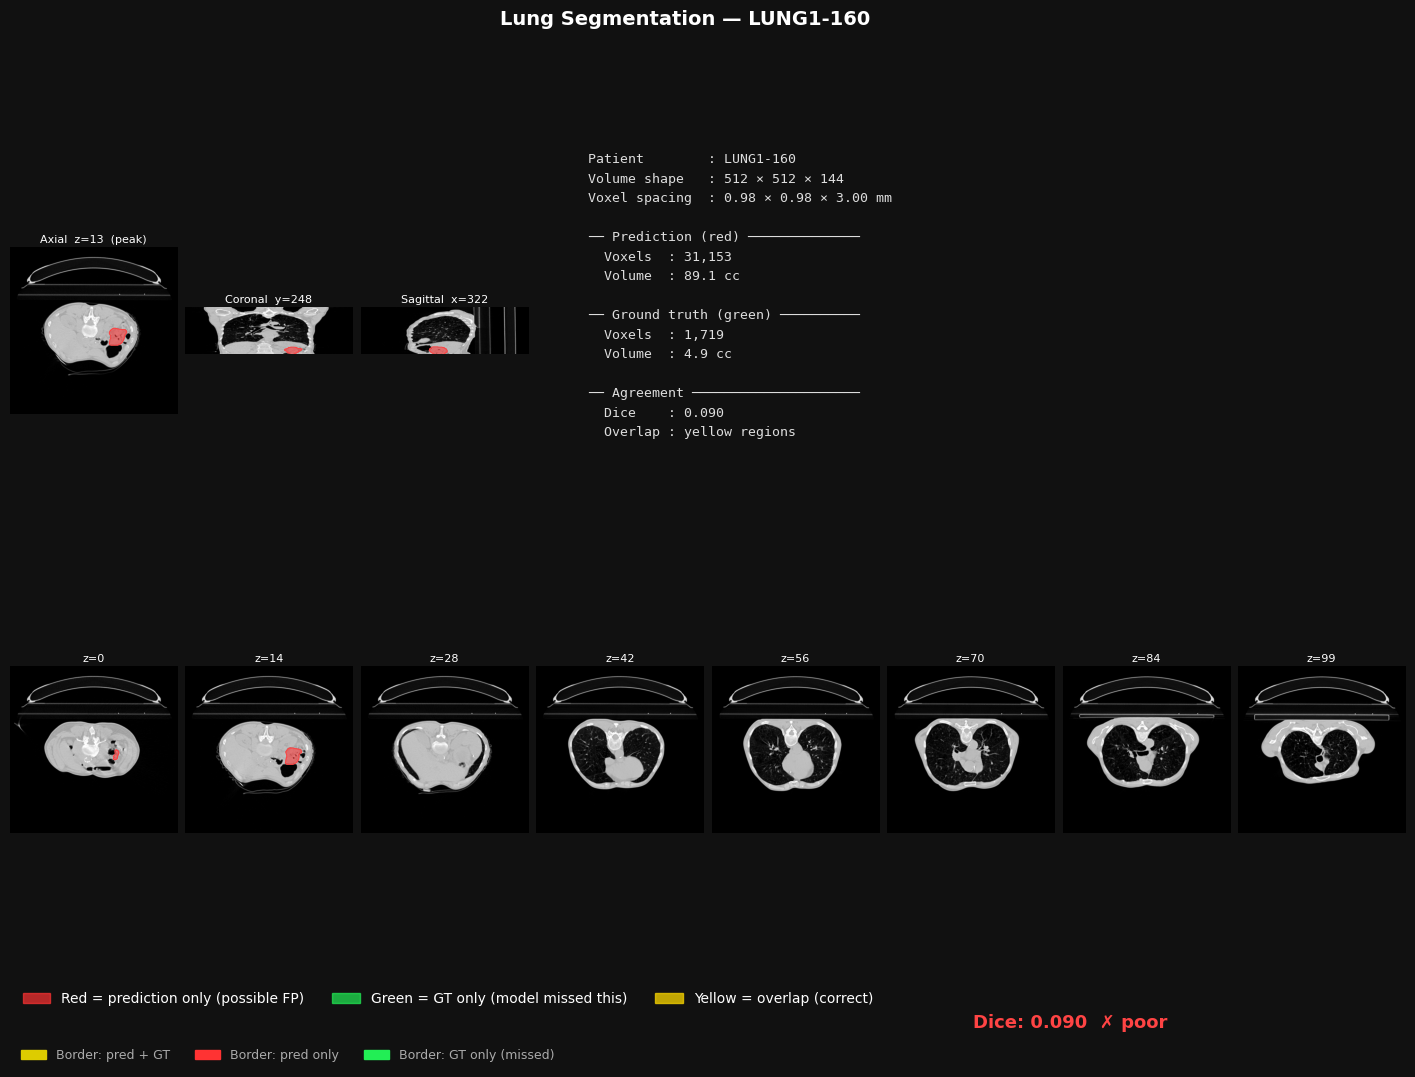


✓ Saved → /content/outputs/LUNG1-160/LUNG1-160_viz.png


In [ ]:

# ════════════════════════════════════════════════════════════════════
# CELL 8 — Visualisation
# @title Edit PATIENT_TO_VIZ below, then run this cell any time.
# ════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path
import nibabel as nib

# ── ▶ Change this to any completed patient ────────────────────────────
PATIENT_TO_VIZ = 'LUNG1-160'

N_STRIP_SLICES = 8     # axial slices shown in bottom strip
# ─────────────────────────────────────────────────────────────────────

# Overlay colors (RGB 0-1)
C_PRED    = (1.0,  0.18, 0.18)   # red    — prediction only
C_GT      = (0.18, 0.9,  0.35)   # green  — ground truth only
C_OVERLAP = (1.0,  0.9,  0.1)    # yellow — overlap


def _find_file(folder, pattern):
    m = list(folder.glob(pattern))
    return m[0] if m else None


def _dice(pred, gt):
    inter = (pred & gt).sum()
    denom = pred.sum() + gt.sum()
    return float(2 * inter / denom) if denom > 0 else float('nan')


def _overlay_rgba(pred_slice, gt_slice):
    """Build RGBA array: red/green/yellow based on pred vs GT regions."""
    rgba = np.zeros((*pred_slice.shape, 4), dtype=np.float32)
    pred_only = (pred_slice == 1) & (gt_slice == 0)
    gt_only   = (pred_slice == 0) & (gt_slice == 1)
    overlap   = (pred_slice == 1) & (gt_slice == 1)
    rgba[pred_only]  = [*C_PRED,    0.55]
    rgba[gt_only]    = [*C_GT,      0.55]
    rgba[overlap]    = [*C_OVERLAP, 0.62]
    return rgba


def _show_slice(ax, ct_sl, pred_sl, gt_sl, title, flip=True):
    ct_d    = ct_sl.T    if flip else ct_sl
    pred_d  = pred_sl.T  if flip else pred_sl
    gt_d    = gt_sl.T    if flip else gt_sl
    rgba    = _overlay_rgba(pred_d, gt_d)

    ax.imshow(ct_d, cmap='gray', origin='lower',
              vmin=ct_d.min(), vmax=ct_d.max())
    ax.imshow(rgba, origin='lower')

    if pred_d.any():
        ax.contour(pred_d, levels=[0.5], colors=['#ff4444'],
                   linewidths=0.75, origin='lower')
    if gt_d.any():
        ax.contour(gt_d,   levels=[0.5], colors=['#22ee55'],
                   linewidths=0.75, origin='lower')

    ax.set_title(title, fontsize=8, color='white', pad=3)
    ax.axis('off')


def visualise_case(patient_id: str):
    folder = Path(f'/content/outputs/{patient_id}')

    if not folder.exists():
        print(f'❌  Folder not found: {folder}')
        avail = [p.name for p in Path('/content/outputs').iterdir() if p.is_dir()] \
                if Path('/content/outputs').exists() else []
        print('    Available cases:', sorted(avail) or 'none yet')
        return

    # ── Load files ────────────────────────────────────────────────────
    mask_path = _find_file(folder, '*_seg_mask.nii.gz')
    ct_path   = _find_file(folder, '*_ct.nii.gz')
    gt_path   = _find_file(folder, '*_gt_mask.nii.gz')

    if mask_path is None:
        print(f'❌  No prediction mask in {folder} — inference not done yet.')
        return

    print(f'Prediction : {mask_path.name}')
    pred_img = nib.load(mask_path)
    pred_arr = pred_img.get_fdata().astype(np.uint8)
    spacing  = pred_img.header.get_zooms()
    nx, ny, nz = pred_arr.shape

    has_ct = ct_path is not None
    ct_arr = (np.clip(nib.load(ct_path).get_fdata().astype(np.float32), -1000, 400)
              if has_ct else np.zeros_like(pred_arr, dtype=np.float32))
    if has_ct:
        print(f'CT         : {ct_path.name}')
    else:
        print('⚠  CT not found — run Cell 5b and re-infer.')

    has_gt = gt_path is not None
    if has_gt:
        print(f'Ground truth: {gt_path.name}')
        gt_raw = nib.load(gt_path).get_fdata().astype(np.uint8)
        # Resample if shape mismatch (rare but possible)
        if gt_raw.shape != pred_arr.shape:
            from scipy.ndimage import zoom
            factors = tuple(p / g for p, g in zip(pred_arr.shape, gt_raw.shape))
            gt_arr  = (zoom(gt_raw.astype(np.float32), factors) > 0.5).astype(np.uint8)
            print(f'  GT resampled {gt_raw.shape} → {pred_arr.shape}')
        else:
            gt_arr = gt_raw
    else:
        print('⚠  GT mask not found — run Cell 5b and re-infer.')
        gt_arr = np.zeros_like(pred_arr)

    # ── Metrics ───────────────────────────────────────────────────────
    pred_vox  = int(pred_arr.sum())
    gt_vox    = int(gt_arr.sum())
    dice      = _dice(pred_arr.astype(bool), gt_arr.astype(bool))
    pred_vol  = pred_vox * np.prod(spacing) / 1000.0
    gt_vol    = gt_vox  * np.prod(spacing) / 1000.0
    dice_str  = f'{dice:.3f}' if not np.isnan(dice) else 'n/a'

    # ── Best slices — union of pred + GT ─────────────────────────────
    union = (pred_arr | gt_arr)
    if union.any():
        ax_slice  = int(np.argmax(union.sum(axis=(0, 1))))
        cor_slice = int(np.argmax(union.sum(axis=(0, 2))))
        sag_slice = int(np.argmax(union.sum(axis=(1, 2))))
    else:
        ax_slice, cor_slice, sag_slice = nz // 2, ny // 2, nx // 2

    # ════════════════════════════════════════════════════════════════
    # Layout
    # ════════════════════════════════════════════════════════════════
    fig = plt.figure(figsize=(18, 12), facecolor='#111111')
    fig.suptitle(f'Lung Segmentation — {patient_id}',
                 color='white', fontsize=14, fontweight='bold', y=0.99)

    gs = gridspec.GridSpec(
        3, max(3, N_STRIP_SLICES),
        figure=fig, hspace=0.38, wspace=0.05,
        height_ratios=[2.2, 1.6, 0.5],
    )

    # ── Row 1: three-plane view ───────────────────────────────────────
    planes = [
        (ct_arr[:, :, ax_slice],  pred_arr[:, :, ax_slice],  gt_arr[:, :, ax_slice],
         f'Axial  z={ax_slice}  (peak)'),
        (ct_arr[:, cor_slice, :], pred_arr[:, cor_slice, :], gt_arr[:, cor_slice, :],
         f'Coronal  y={cor_slice}'),
        (ct_arr[sag_slice, :, :], pred_arr[sag_slice, :, :], gt_arr[sag_slice, :, :],
         f'Sagittal  x={sag_slice}'),
    ]
    for col, (ct_sl, pr_sl, gt_sl, lbl) in enumerate(planes):
        _show_slice(fig.add_subplot(gs[0, col]), ct_sl, pr_sl, gt_sl, lbl)

    # ── Stats panel (right of 3-plane) ───────────────────────────────
    if N_STRIP_SLICES > 3:
        ax_info = fig.add_subplot(gs[0, 3:])
        ax_info.set_facecolor('#111111')
        ax_info.axis('off')
        lines = [
            f'Patient        : {patient_id}',
            f'Volume shape   : {nx} × {ny} × {nz}',
            f'Voxel spacing  : {spacing[0]:.2f} × {spacing[1]:.2f} × {spacing[2]:.2f} mm',
            '',
            '── Prediction (red) ──────────────',
            f'  Voxels  : {pred_vox:,}',
            f'  Volume  : {pred_vol:.1f} cc',
            '',
            '── Ground truth (green) ──────────',
            f'  Voxels  : {gt_vox:,}' if has_gt else '  not available',
            f'  Volume  : {gt_vol:.1f} cc' if has_gt else '',
            '',
            '── Agreement ─────────────────────',
            f'  Dice    : {dice_str}',
            f'  Overlap : yellow regions',
        ]
        ax_info.text(
            0.06, 0.97, '\n'.join(lines),
            transform=ax_info.transAxes, va='top', ha='left',
            fontsize=9.5, color='#dddddd',
            fontfamily='monospace', linespacing=1.65,
        )

    # ── Row 2: axial strip ────────────────────────────────────────────
    union_z = np.where(union.sum(axis=(0, 1)) > 0)[0]
    if len(union_z):
        pad = max(4, int(len(union_z) * 0.15))
        z0  = max(0, union_z[0] - pad)
        z1  = min(nz - 1, union_z[-1] + pad)
    else:
        z0, z1 = 0, nz - 1

    for col_i, z in enumerate(np.linspace(z0, z1, N_STRIP_SLICES, dtype=int)):
        ax_s = fig.add_subplot(gs[1, col_i])
        has_p = bool(pred_arr[:, :, z].any())
        has_g = bool(gt_arr[:, :, z].any())

        _show_slice(ax_s,
                    ct_arr[:, :, z], pred_arr[:, :, z], gt_arr[:, :, z],
                    f'z={z}')

        # Border color encodes annotation type
        if has_p and has_g:
            border, lw = '#ddcc00', 2.2    # both
        elif has_p:
            border, lw = '#ff3333', 1.8    # pred only
        elif has_g:
            border, lw = '#22ee55', 1.8    # GT only (missed)
        else:
            border, lw = '#2a2a2a', 0.5

        for spine in ax_s.spines.values():
            spine.set_edgecolor(border)
            spine.set_linewidth(lw)

    # ── Row 3: legend ─────────────────────────────────────────────────
    ax_leg = fig.add_subplot(gs[2, :])
    ax_leg.set_facecolor('#111111')
    ax_leg.axis('off')

    overlay_legend = ax_leg.legend(
        handles=[
            mpatches.Patch(color='#ff3333', alpha=0.7,
                           label='Red = prediction only (possible FP)'),
            mpatches.Patch(color='#22ee55', alpha=0.7,
                           label='Green = GT only (model missed this)'),
            mpatches.Patch(color='#eecc00', alpha=0.8,
                           label='Yellow = overlap (correct)'),
        ],
        loc='center left', ncol=3, frameon=False,
        labelcolor='white', fontsize=10,
        bbox_to_anchor=(0.0, 0.78),
    )

    ax_leg.legend(
        handles=[
            mpatches.Patch(color='#ddcc00', label='Border: pred + GT'),
            mpatches.Patch(color='#ff3333', label='Border: pred only'),
            mpatches.Patch(color='#22ee55', label='Border: GT only (missed)'),
        ],
        loc='center left', ncol=3, frameon=False,
        labelcolor='#aaaaaa', fontsize=9,
        bbox_to_anchor=(0.0, 0.12),
    )
    ax_leg.add_artist(overlay_legend)

    # Dice badge
    dice_color = ('#22ee55' if not np.isnan(dice) and dice >= 0.5
                  else '#ff8833' if not np.isnan(dice) and dice >= 0.3
                  else '#ff4444')
    badge = ('✓ good' if not np.isnan(dice) and dice >= 0.5
             else '⚠ partial' if not np.isnan(dice) and dice >= 0.3
             else ('✗ poor' if not np.isnan(dice) else 'no GT'))
    ax_leg.text(
        0.76, 0.5, f'Dice: {dice_str}  {badge}',
        transform=ax_leg.transAxes, ha='center', va='center',
        fontsize=13, fontweight='bold', color=dice_color,
    )

    out_png = folder / f'{patient_id}_viz.png'
    plt.savefig(str(out_png), dpi=140, bbox_inches='tight', facecolor='#111111')
    plt.show()
    print(f'\n✓ Saved → {out_png}')
    if not has_ct:
        print('💡 Re-run Cell 5b then re-infer to get CT background.')
    if not has_gt:
        print('💡 Re-run Cell 5b then re-infer to get GT mask for Dice score.')


# ── Run ───────────────────────────────────────────────────────────────
visualise_case(PATIENT_TO_VIZ)

In [ ]:
!rm -rf content/outputs/LUNG1-156